In [1]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat

from matplotlib import pyplot as plt
from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test) 

                                        if os.path.exists(event_dir):
                                            # print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, "availability": av,
                                                "alpha": a, "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "test_loss": "Test/Loss",
                                                "train_accuracy": "Train/Metric",
                                                "train_loss": "Train/Loss",
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

In [3]:
main_folder = 'model_quality'
def modify_data(_df):
    tmp = _df.groupby(['algorithm', 'availability','lr', 'alpha']).test_accuracy.apply(np.vstack).to_frame().reset_index()
    tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
    tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
    tmp['std_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.std(axis=0))
    tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
    tmp['final_var_acc'] = tmp['var_test_acc'].apply(lambda x : x[-1])
    tmp['final_std_acc'] = tmp['std_test_acc'].apply(lambda x : x[-1])
    tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
    tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))
    return tmp

def get_plt(tmp, data_type, ft=True):
    # Filter and process data for FedAvg
    fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
    fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)

    # Filter and process data for FedVarp
    fedvarp = tmp.loc[(tmp['algorithm'] == 'fedvarp') & (tmp['alpha'] == data_type)]
    fedvarp['avail_mat'] = fedvarp['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)

    # Plot
    plt.figure(figsize=(10, 8))

    # Plot for FedAvg with lr differentiation
    for lr_value in fed_avg['lr'].unique():
        subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
        plt.plot(
            subset['avail_mat'], subset['final_mean_acc'], 
            marker='o', label=f'FedAvg (lr={lr_value})'
        )
        plt.fill_between(
            subset['avail_mat'], 
            subset['final_mean_acc'] - subset['final_var_acc'], 
            subset['final_mean_acc'] + subset['final_var_acc'], 
            alpha=0.2
        )

    # Plot for FedVarp with lr differentiation
    for lr_value in fedvarp['lr'].unique():
        subset = fedvarp[fedvarp['lr'] == lr_value].sort_values('avail_mat')
        plt.plot(
            subset['avail_mat'], subset['final_mean_acc'], 
            marker='o', linestyle='--', label=f'FedVarp (lr={lr_value})'
        )
        plt.fill_between(
            subset['avail_mat'], 
            subset['final_mean_acc'] - subset['final_var_acc'], 
            subset['final_mean_acc'] + subset['final_var_acc'], 
            alpha=0.2
        )
        

    # Add labels and legend
    plt.xlabel('Carbon Budget', fontsize=12)
    plt.ylabel('Final Test Accuracy (with Variance)', fontsize=12)
    plt.title(f'{data_type} case {"with" if ft else "no"} ft', fontsize=14)
    plt.grid(visible=True, which='both')
    plt.minorticks_on()  # Enable minor ticks for finer granularity
    plt.ylim(0,1)
    plt.legend()
    plt.show()



In [4]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.1", "0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-alpha0.001-8cb alphaF50-alpha0.01-8cb alphaF50-alpha0.1-8cb alphaF50-alpha0.5-8cb alphaF50-alpha0.75-8cb alphaF50-alpha0.9-8cb alphaF50-alpha1.0-8cb".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

2025-05-13 22:35:54.799108: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747155955.317540   81081 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747155955.468850   81081 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747155956.576021   81081 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747155956.576052   81081 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747155956.576057   81081 computation_placer.cc:177] computation placer alr

In [9]:
tmp = modify_data(results_df)

In [10]:
# Extract avail_mat
tmp['alpha_val'] = tmp['availability'].str.extract(r'-alpha([\d.]+)-')

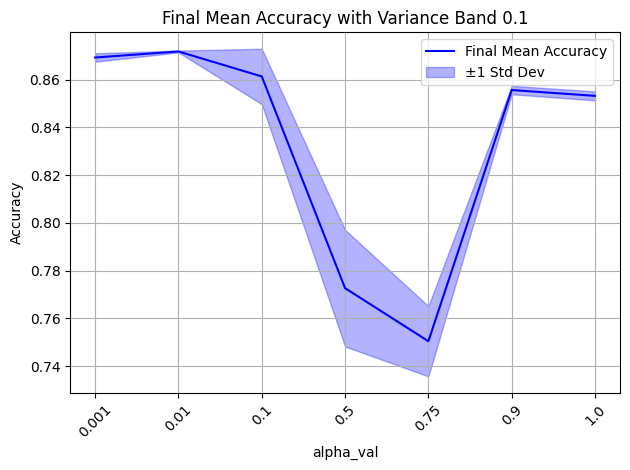

In [14]:
data_type="0.1"
fed_avg = tmp.loc[tmp['alpha'] == data_type]
mean = fed_avg['final_mean_acc']
std = np.sqrt(fed_avg['final_var_acc'])

x = range(len(fed_avg))
labels = fed_avg['alpha_val']

plt.plot(x, mean, label='Final Mean Accuracy', color='blue')
plt.fill_between(x, mean - std, mean + std, alpha=0.3, color='blue', label='±1 Std Dev')

plt.xticks(ticks=x, labels=labels, rotation=45)
plt.xlabel('alpha_val')
plt.ylabel('Accuracy')
plt.title(f'Final Mean Accuracy with Variance Band {data_type}')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

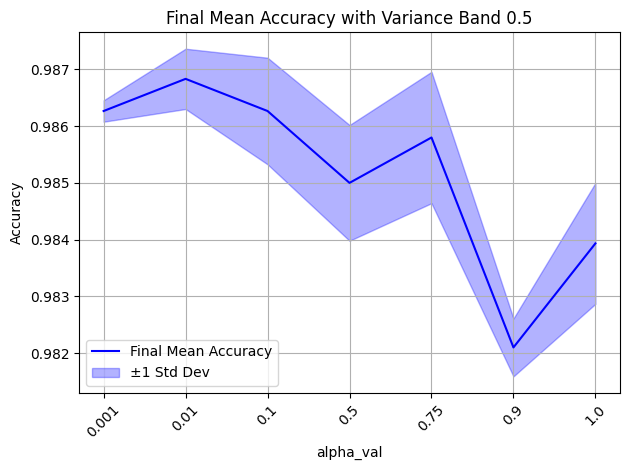

In [15]:
data_type="0.5"
fed_avg = tmp.loc[tmp['alpha'] == data_type]
mean = fed_avg['final_mean_acc']
std = np.sqrt(fed_avg['final_var_acc'])

x = range(len(fed_avg))
labels = fed_avg['alpha_val']

plt.plot(x, mean, label='Final Mean Accuracy', color='blue')
plt.fill_between(x, mean - std, mean + std, alpha=0.3, color='blue', label='±1 Std Dev')

plt.xticks(ticks=x, labels=labels, rotation=45)
plt.xlabel('alpha_val')
plt.ylabel('Accuracy')
plt.title(f'Final Mean Accuracy with Variance Band {data_type}')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()